In [2]:
from __future__ import annotations

# LOAD THE DATASET

In [3]:
import json

with open("orbito_dataset_whole.jsonl") as file:
    raw_records = [json.loads(line) for line in file]
len(raw_records)

728284

In [4]:
Vec2I = tuple[int, int]

In [5]:
from dataclasses import dataclass

import torch


@dataclass(frozen=True)
class Record:
    board: torch.Tensor
    move: tuple[Vec2I, Vec2I] | None
    place: Vec2I

    @classmethod
    def of_dict(cls, record: dict) -> Record:
        mv = record["move"]
        return Record(
            board=torch.tensor([record["board"]], dtype=torch.float),
            move=None if not mv else (tuple(mv["src"]), tuple(mv["dst"])),
            place=tuple(record["place"]["spot"]),
        )


Record.of_dict(raw_records[0])

Record(board=tensor([[[-1.,  1., -1.,  0.],
         [-1.,  0.,  1.,  0.],
         [ 1.,  1., -1.,  0.],
         [ 1., -1.,  0.,  0.]]]), move=None, place=(3, 2))

In [6]:
records = [Record.of_dict(raw) for raw in raw_records]

# BOARD MECHANICS

In [7]:
BOARD_SIZE = 4


def rotate_board(board: torch.Tensor) -> torch.Tensor:
    next_board = torch.zeros(BOARD_SIZE, BOARD_SIZE, dtype=board.dtype)
    next_board[1:3, 1:3] = board[1:3, 1:3].rot90()

    next_board[0, :3] = board[0, 1:]
    next_board[3, 1:] = board[3, :3]
    next_board[1:, 0] = board[:3, 0]
    next_board[:3, 3] = board[1:, 3]

    return next_board

In [8]:
def add_vec(v1: Vec2I, v2: Vec2I) -> Vec2I:
    return v1[0] + v2[0], v1[1] + v2[1]


def sub_vec(v1: Vec2I, v2: Vec2I) -> Vec2I:
    return v1[0] - v2[0], v1[1] - v2[1]

In [9]:
def apply_move_direction(
    board: torch.Tensor,
    src: tuple[int, int],
    dir: tuple[int, int],
) -> torch.Tensor:
    dst = add_vec(src, dir)
    moved = board.clone()
    moved[dst] = moved[src]
    moved[src] = 0
    return moved

In [10]:
board = torch.Tensor(records[0].board)
board, apply_move_direction(board[0], (2, 0), (0, 1))

(tensor([[[-1.,  1., -1.,  0.],
          [-1.,  0.,  1.,  0.],
          [ 1.,  1., -1.,  0.],
          [ 1., -1.,  0.,  0.]]]),
 tensor([[-1.,  1., -1.,  0.],
         [-1.,  0.,  1.,  0.],
         [ 0.,  1., -1.,  0.],
         [ 1., -1.,  0.,  0.]]))

# Helper Functions

In [11]:
from functools import cache
from itertools import product

up = (-1, 0)
down = (1, 0)
left = (0, -1)
right = (0, 1)


@cache
def get_move_map() -> dict[tuple[Vec2I, Vec2I], int]:
    move_map: dict[tuple[Vec2I, Vec2I], int] = {}
    board_coords = product(range(BOARD_SIZE), range(BOARD_SIZE))
    i = 1
    for y, x in board_coords:
        if y > 0:
            move_map[((y, x), (up))] = i
            i += 1
        if y < BOARD_SIZE - 1:
            move_map[((y, x), (down))] = i
            i += 1
        if x > 0:
            move_map[((y, x), (left))] = i
            i += 1
        if x < BOARD_SIZE - 1:
            move_map[((y, x), (right))] = i
            i += 1

    return move_map


move_dir_to_int = get_move_map()
int_to_move_dir = {v: k for k, v in move_dir_to_int.items()}

MOVE_OPTIONS = len(move_dir_to_int) + 1  # moves + no move idx

In [12]:
def move_to_int(move: tuple[Vec2I, Vec2I] | None) -> int:
    if move is None:
        return 0

    src, dst = move
    dir = sub_vec(dst, src)
    return move_dir_to_int[(src, dir)]


def int_to_move(n: int) -> Vec2I | None:
    if n == 0:
        return None
    src, dir = int_to_move_dir[n]
    return add_vec(src, dir)

In [13]:
_place_to_int = {
    coord: i for i, coord in enumerate(product(range(BOARD_SIZE), range(BOARD_SIZE)))
}
_int_to_place = {v: k for k, v in _place_to_int.items()}


def place_to_int(place: Vec2I) -> int:
    return _place_to_int[place]


def int_to_place(n: int) -> Vec2I:
    return _int_to_place[n]

In [14]:
from collections.abc import Callable

PLAYER = -1
FREE_SPOT = 0


def mask_move_tensor_idxs(device: str) -> Callable[[torch.Tensor], torch.Tensor]:
    def inner(board: torch.Tensor) -> torch.Tensor:
        mask = torch.ones(MOVE_OPTIONS, device=device)
        to_mask: list[tuple[Vec2I, Vec2I]] = []
        for pos in product(range(BOARD_SIZE), range(BOARD_SIZE)):
            y, x = pos
            if board[pos] != PLAYER:
                to_mask.extend([(pos, up), (pos, down), (pos, left), (pos, right)])
                continue

            if y > 0 and board[add_vec(pos, up)] != FREE_SPOT:
                to_mask.append((pos, up))

            if y < BOARD_SIZE - 1 and board[add_vec(pos, down)] != FREE_SPOT:
                to_mask.append((pos, down))

            if x > 0 and board[add_vec(pos, left)] != FREE_SPOT:
                to_mask.append((pos, left))

            if x < BOARD_SIZE - 1 and board[add_vec(pos, right)] != FREE_SPOT:
                to_mask.append((pos, right))

        for pos_dir in to_mask:
            if pos_dir not in move_dir_to_int:
                continue
            move_mask_idx = move_dir_to_int[pos_dir]
            mask[move_mask_idx] = float("-inf")
        return mask

    return inner


def mask_place_tensor_idxs(device: str) -> Callable[[torch.Tensor], torch.Tensor]:
    def inner(board: torch.Tensor) -> torch.Tensor:
        mask = torch.ones(BOARD_SIZE * BOARD_SIZE, device=device)
        for pos in product(range(BOARD_SIZE), range(BOARD_SIZE)):
            if board[pos] != 0:
                mask[place_to_int(pos)] = float("-inf")
        return mask

    return inner

In [15]:
import torch.nn.functional as F


def build_move_index_buffers(device: str) -> dict[str, torch.Tensor]:
    dirs = {"up": up, "down": down, "left": left, "right": right}
    idx_maps = {}
    for name, d in dirs.items():
        flat = torch.full((BOARD_SIZE * BOARD_SIZE,), -1, dtype=torch.long)
        for pos in product(range(BOARD_SIZE), range(BOARD_SIZE)):
            key = (pos, d)
            if key in move_dir_to_int:
                flat_pos = pos[0] * BOARD_SIZE + pos[1]
                flat[flat_pos] = move_dir_to_int[key]
        idx_maps[name] = flat.to(device)
    return idx_maps


def mask_move_tensor_idxs_vectorized(
    device: str,
) -> Callable[[torch.Tensor], torch.Tensor]:
    idx_maps = build_move_index_buffers(device)

    def inner(board: torch.Tensor) -> torch.Tensor:
        if board.dim() == 2:
            board = board.unsqueeze(0)

        N = board.shape[0]
        is_player = board == PLAYER

        neighbors = {
            "up": F.pad(board, (0, 0, 1, 0))[:, :-1, :],
            "down": F.pad(board, (0, 0, 0, 1))[:, 1:, :],
            "left": F.pad(board, (1, 0, 0, 0))[:, :, :-1],
            "right": F.pad(board, (0, 1, 0, 0))[:, :, 1:],
        }

        mask = torch.zeros(N, MOVE_OPTIONS, device=device)

        for name, neighbor in neighbors.items():
            legal = is_player & (neighbor == FREE_SPOT)
            legal_flat = legal.view(N, -1)

            idx = idx_maps[name]
            valid = idx >= 0
            cols = idx[valid]
            illegal = ~legal_flat[:, valid]

            mask[:, cols] = torch.where(
                illegal,
                torch.tensor(float("-inf"), device=device),
                mask[:, cols],
            )

        return mask

    return inner


def mask_place_tensor_idxs_vectorized(
    device: str,
) -> Callable[[torch.Tensor], torch.Tensor]:
    def inner(board: torch.Tensor) -> torch.Tensor:
        if board.dim() == 2:
            board = board.unsqueeze(0)

        N = board.shape[0]
        occupied_flat = (board != FREE_SPOT).view(N, -1)

        return torch.where(
            occupied_flat,
            torch.tensor(float("-inf"), device=device),
            torch.tensor(0.0, device=device),
        )

    return inner

In [16]:
def apply_record_move(
    board: torch.Tensor, move: tuple[Vec2I, Vec2I] | None
) -> torch.Tensor:
    if move is None:
        return board.clone()
    src, dst = move
    dir = sub_vec(dst, src)
    moved = apply_move_direction(board[0], src, dir)
    return moved.unsqueeze(0)


@torch.no_grad()
def find_broken_records(records: list[Record]) -> list[dict]:
    mask_move = mask_move_tensor_idxs_vectorized("cpu")
    mask_place = mask_place_tensor_idxs_vectorized("cpu")

    broken = []
    for i, record in enumerate(records):
        board = record.board.float()

        move_target = move_to_int(record.move)
        move_mask = mask_move(board).squeeze(0)
        if torch.isinf(move_mask[move_target]):
            broken.append({"idx": i, "phase": "move", "record": record})
            continue

        next_board = apply_record_move(board, record.move)
        place_target = place_to_int(record.place)
        place_mask = mask_place(next_board).squeeze(0)
        if torch.isinf(place_mask[place_target]):
            broken.append({"idx": i, "phase": "place", "record": record})

    return broken


# broken = find_broken_records(records)
# len(broken), len(broken) / len(records)

In [17]:
def turn_loss(model, record: Record) -> torch.Tensor:
    board = record.board.float().to(DEVICE)

    move_logits = model(board, can_move=True)
    move_target = torch.tensor(move_to_int(record.move), device=DEVICE)
    move_loss = F.cross_entropy(move_logits.unsqueeze(0), move_target.unsqueeze(0))

    next_board = apply_record_move(board, record.move)
    place_logits = model(next_board, can_move=False)
    place_target = torch.tensor(place_to_int(record.place), device=DEVICE)
    place_loss = F.cross_entropy(place_logits.unsqueeze(0), place_target.unsqueeze(0))

    return move_loss + place_loss

In [18]:
import random

random.seed(42)
shuffled = records.copy()
random.shuffle(shuffled)

VALID_FRACTION = 0.1
split_idx = int(len(shuffled) * (1 - VALID_FRACTION))
train_records = shuffled[:split_idx]
valid_records = shuffled[split_idx:]

len(train_records), len(valid_records)

(655455, 72829)

In [19]:
@torch.no_grad()
def evaluate(model, valid_records: list[Record], n_turns: int = 10) -> float:
    model.eval()
    sample = random.sample(valid_records, k=min(n_turns, len(valid_records)))
    losses = [turn_loss(model, r).item() for r in sample]
    model.train()
    return sum(losses) / len(losses)

In [20]:
from torch import optim


def train(
    model,
    epochs: int,
    valid_every: int,
    batch_size: int,
    max_examples: int | None = None,
) -> tuple:
    optimizer = optim.AdamW(model.parameters(), lr=5e-4)
    train_history: list[tuple[int, float]] = []
    valid_history: list[tuple[int, float]] = []

    step = 0
    model.train()
    optimizer.zero_grad()
    max_examples = max_examples if max_examples is not None else len(train_records)
    for epoch in range(epochs):
        random.shuffle(train_records)
        for i, record in enumerate(train_records[:max_examples]):
            loss = turn_loss(model, record) / batch_size
            loss.backward()

            if (i + 1) % batch_size == 0:
                optimizer.step()
                optimizer.zero_grad()

            train_history.append((step, loss.item() * batch_size))

            if step % valid_every == 0:
                valid_loss = evaluate(model, valid_records, n_turns=10)
                valid_history.append((step, valid_loss))
                train_loss = loss.item() * batch_size
                print(
                    f"epoch {epoch} step {step}: train={train_loss:.4f} valid={valid_loss:.4f}"
                )

            step += 1

        if (i + 1) % batch_size != 0:
            optimizer.step()
            optimizer.zero_grad()
    return train_history, valid_history

In [21]:
def train_fixed_subset(model, epochs, valid_every, batch_size, subset):
    optimizer = optim.AdamW(model.parameters(), lr=5e-4)
    train_history, valid_history = [], []
    step = 0
    model.train()
    optimizer.zero_grad()
    for epoch in range(epochs):
        random.shuffle(subset)
        for i, record in enumerate(subset):
            loss = turn_loss(model, record) / batch_size
            loss.backward()
            if (i + 1) % batch_size == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
            train_history.append((step, loss.item() * batch_size))
            if step % valid_every == 0:
                valid_loss = evaluate(model, subset, n_turns=len(subset))
                valid_history.append((step, valid_loss))
            step += 1
        if (i + 1) % batch_size != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
    return train_history, valid_history

In [22]:
import matplotlib.pyplot as plt


def moving_average(values: list[float], window: int = 50) -> list[float]:
    out = []
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        out.append(sum(values[lo : i + 1]) / (i - lo + 1))
    return out


def show_losses(train_history, valid_history) -> None:
    train_steps, train_vals = zip(*train_history)
    valid_steps, valid_vals = zip(*valid_history)

    plt.figure(figsize=(10, 5))
    plt.plot(train_steps, train_vals, alpha=0.15, color="tab:blue")
    plt.plot(
        train_steps,
        moving_average(list(train_vals)),
        label="train (smoothed)",
        color="tab:blue",
    )
    plt.plot(valid_steps, valid_vals, label="valid", marker="o", color="tab:orange")
    plt.xlabel("step")
    plt.ylabel("loss (move + place)")
    plt.legend()
    plt.title("Training progress")
    plt.show()

# Model Definition

In [ ]:
from torch import nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def num_params(model) -> int:
    return sum(map(len, model.parameters()))

In [ ]:
class MovePlaceFFLayerCNN(nn.Module):
    def __init__(self, channels: int, ff_factor: int) -> None:
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=channels,
                kernel_size=(BOARD_SIZE, BOARD_SIZE),
                device=DEVICE,
            ),
            nn.Flatten(),
            nn.ReLU(),
        )
        self.ff = nn.Sequential(
            nn.Linear(channels, channels * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels * ff_factor, channels * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels * ff_factor, channels * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels * ff_factor, channels * ff_factor, device=DEVICE),
            nn.ReLU(),
        )
        self.move_logits = nn.Linear(channels * ff_factor, MOVE_OPTIONS, device=DEVICE)
        self.place_logits = nn.Linear(
            channels * ff_factor, BOARD_SIZE * BOARD_SIZE, device=DEVICE
        )
        self.mask_move = mask_move_tensor_idxs_vectorized(DEVICE)
        self.mask_place = mask_place_tensor_idxs_vectorized(DEVICE)
        with torch.no_grad():
            self.move_logits.weight *= 0.1
            self.place_logits.weight *= 0.1

    def to_board_batch(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            return x[0].unsqueeze(0)
        elif x.dim() == 4:
            return x[:, 0]
        raise ValueError(f"Unexpected shape: {x.shape}")

    def forward(self, x, can_move: bool = True):
        conved = self.conv(x).view(-1)
        ff_x = self.ff(conved)
        board_batch = self.to_board_batch(x)

        out = (
            self.move_logits(ff_x) + self.mask_move(board_batch).squeeze(0)
            if can_move
            else self.place_logits(ff_x) + self.mask_place(board_batch).squeeze(0)
        )
        return out

# Benchmarking

    8450: loss: 0.1210


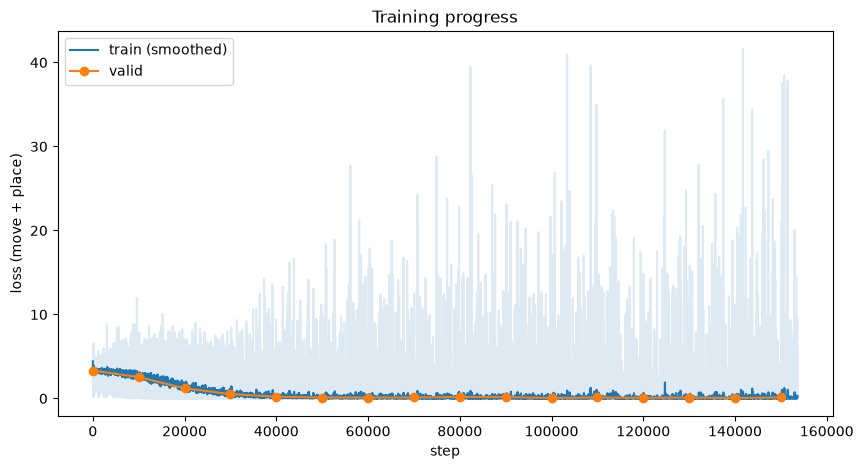

In [40]:
overfit_model = MovePlaceFFLayerCNN(
    channels=64,
    ff_factor=16,
)


small = train_records[:2048]
train_history, valid_history = train_fixed_subset(
    overfit_model, epochs=75, valid_every=10000, batch_size=8, subset=small
)


print(f"{num_params(overfit_model):>8}: loss: {valid_history[-1][1]:.4f}")

show_losses(train_history, valid_history)

### CNN -> 4 Layers FF -> 2x Logit Layer (Move/Place)

| Channels | FF-Factor | Params |Subset-Length  | Epochs | Batch-Size |  Loss  |   Fits-At (k steps) | Time |
|---------:|----------:|-------:|--------------:|-------:|-----------:|-------:| -------------:| ----:|
| 64       | 16        | 8450   | 64            | 200    | 8          | 0.0000 | 2.2           |      |
| 64       | 16        | 8450   | 128           | 200    | 8          | 0.0000 | 7             |      |
| 64       | 16        | 8450   | 256           | 200    | 8          | 0.0000 | 10            |      |
| 64       | 16        | 8450   | 512           | 200    | 8          | 0.0000 | 17.5          |      |
| 64       | 16        | 8450   | 1024          | 150    | 8          | 0.0000 | 35            |      |
| 64       | 16        | 8450   | 2048          | 75     | 8          | 0.0000 | 60            | 11m  |
| 64       | 16        | 8450   | 4096          | 40+20+20  | 8          | 0.1015 -> 0.0439 -> 0.0430| Doesnt fit    | 16m+8m+8m  |
| 64       | 16        | 8450   | 2048          | 75  | 16          | 0.0000 | 80    | 8m  |
| 128      | 32        | 33154   | 4096          | 100  | 16          | 0.0004 | 375   | 1h20m  |

| Channels | FF-Factor | Params |Subset-Length  | Epochs | Batch-Size |  Loss  |   Fits-At (k steps) | 
|---------:|----------:|-------:|--------------:|-------:|-----------:|-------:| -------------:|
| 8        | 1         | 210    | 32            | 200    | 8          | 1.7319 | Doesn't fit   |
| 16       | 1         | 290    | 32            | 200    | 8          | 1.3268 | Doesn't fit   |
| 32       | 1         | 450    | 32            | 200    | 8          | 0.1728 | 6             |
| 64       | 1         | 770    | 32            | 200    | 8          | 0.0154 | 5.5           |
| 8        | 2         | 274    | 32            | 200    | 8          | 1.4417 | Doesn't fit   |
| 16       | 2         | 418    | 32            | 200    | 8          | 0.1556 | 6             |
| 32       | 2         | 706    | 32            | 200    | 8          | 0.0048 | 4.5           |
| 64       | 2         | 1282   | 32            | 200    | 8          | 0.0005 | 3.5           |
| 8        | 4         | 402    | 32            | 200    | 8          | 0.4545 | Doesn't fit   |
| 32       | 4         | 1218   | 32            | 200    | 8          | 0.0009 | 4             |
| 64       | 4         | 2306   | 32            | 200    | 8          | 0.0002 | 2             |
| 8        | 8         | 658    | 32            | 200    | 8          | 0.0750 | Doesn't fit   |
| 8        | 16        | 1186   | 32            | 200    | 8          | 0.0011 | 3.5           |
| 16       | 16        | 2210   | 32            | 200    | 8          | 0.0002 | 2             |
| 32       | 16        | 4290   | 32            | 200    | 8          | 0.0001 | 1.2           |
| 64       | 16        | 8450   | 32            | 200    | 8          | 0.0000 | 1.1           |

In [26]:
class Transformer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, ff_factor: int) -> None:
        super().__init__()
        self.cell_emb = nn.Embedding(3, d_model, device=DEVICE)
        self.pos_emb = nn.Parameter(
            torch.randn(BOARD_SIZE * BOARD_SIZE, d_model, device=DEVICE) * 0.02,
        )
        self.attention = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model,
                n_heads,
                dim_feedforward=d_model * 2,
                dropout=0.0,
                batch_first=True,
                device=DEVICE,
            ),
            num_layers=4,
        )
        self.ff = nn.Sequential(
            nn.Linear(
                BOARD_SIZE * BOARD_SIZE * d_model, d_model * ff_factor, device=DEVICE
            ),
            nn.ReLU(),
            nn.Linear(d_model * ff_factor, d_model * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(d_model * ff_factor, d_model * ff_factor, device=DEVICE),
            nn.ReLU(),
        )
        self.move_logits = nn.Linear(d_model * ff_factor, MOVE_OPTIONS, device=DEVICE)
        self.place_logits = nn.Linear(
            d_model * ff_factor, BOARD_SIZE * BOARD_SIZE, device=DEVICE
        )
        self.mask_move = mask_move_tensor_idxs_vectorized(DEVICE)
        self.mask_place = mask_place_tensor_idxs_vectorized(DEVICE)
        with torch.no_grad():
            self.move_logits.weight *= 0.1
            self.place_logits.weight *= 0.1

    def to_board_batch(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            return x[0].unsqueeze(0)
        elif x.dim() == 4:
            return x[:, 0]
        raise ValueError(f"Unexpected shape: {x.shape}")

    def forward(self, x, can_move: bool = True):
        tokens = x.reshape(-1).long() + 1
        h = self.cell_emb(tokens) + self.pos_emb
        h = self.attention(h.unsqueeze(0)).reshape(-1)
        ff_x = self.ff(h)
        board_batch = self.to_board_batch(x)

        out = (
            self.move_logits(ff_x) + self.mask_move(board_batch).squeeze(0)
            if can_move
            else self.place_logits(ff_x) + self.mask_place(board_batch).squeeze(0)
        )
        return out

   49301: loss: 3.2534


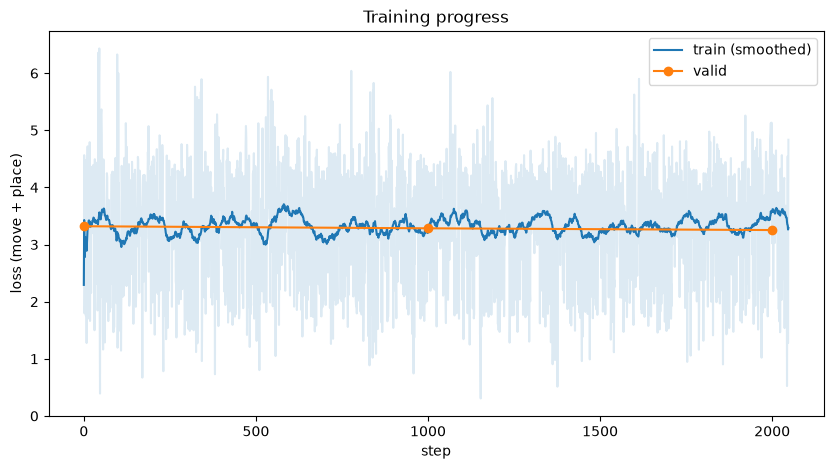

In [ ]:
overfit_model = Transformer(
    d_model=512,
    n_heads=8,
    ff_factor=4,
)

small = train_records[:2048]
train_history, valid_history = train_fixed_subset(
    overfit_model, epochs=1, valid_every=1000, batch_size=4, subset=small
)


print(f"{num_params(overfit_model):>8}: loss: {valid_history[-1][1]:.4f}")

show_losses(train_history, valid_history)

| d_model | n_heads | FF-Factor | Params |Subset-Length  | Epochs | Batch-Size |  Loss  |   Fits-At (k steps) | Time |
|--------:|--------:|----------:|-------:|--------------:|-------:|-----------:|-------:| -------------------:| ----:|
|       8 |       2 |         1 |    453 |            32 | 300    | 4          | 0.0090 |                   6 | 45s  |
|       8 |       4 |         1 |    453 |            32 | 300    | 4          | 0.0096 |                   6 | 42s  |
|      16 |       2 |         1 |    757 |            32 | 200    | 4          | 0.0064 |                   4 | 28s  |
|      16 |       4 |         1 |    757 |            32 | 200    | 4          | 0.0071 |                   3 | 30s  |
|       8 |       4 |         1 |    453 |            64 | 200    | 4          | 0.0071 |                  12 | 1m3s |
|       8 |       4 |         2 |    469 |            64 | 200    | 4          | 0.0093 |                   8 | 1m5s |
|      16 |       2 |         2 |    789 |            64 | 200    | 4          | 0.0019 |                   4 | 1m2s |

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self, d_model: int) -> None:
        super().__init__()
        self.ff = nn.Sequential(
            nn.Flatten(),
            nn.Linear(BOARD_SIZE * BOARD_SIZE, d_model, device=DEVICE),
            nn.ReLU(),
            nn.Linear(d_model, d_model, device=DEVICE),
            nn.ReLU(),
            nn.Linear(d_model, d_model, device=DEVICE),
            nn.ReLU(),
            nn.Linear(d_model, d_model, device=DEVICE),
            nn.ReLU(),
            nn.Linear(d_model, d_model, device=DEVICE),
            nn.ReLU(),
        )
        self.move_logits = nn.Linear(d_model, MOVE_OPTIONS, device=DEVICE)
        self.place_logits = nn.Linear(d_model, BOARD_SIZE * BOARD_SIZE, device=DEVICE)
        self.mask_move = mask_move_tensor_idxs_vectorized(DEVICE)
        self.mask_place = mask_place_tensor_idxs_vectorized(DEVICE)
        with torch.no_grad():
            self.move_logits.weight *= 0.1
            self.place_logits.weight *= 0.1

    def to_board_batch(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            return x[0].unsqueeze(0)
        elif x.dim() == 4:
            return x[:, 0]
        raise ValueError(f"Unexpected shape: {x.shape}")

    def forward(self, x, can_move: bool = True):
        ff_x = self.ff(x).view(-1)
        board_batch = self.to_board_batch(x)

        out = (
            self.move_logits(ff_x) + self.mask_move(board_batch).squeeze(0)
            if can_move
            else self.place_logits(ff_x) + self.mask_place(board_batch).squeeze(0)
        )
        return out

    6274: loss: 0.0069


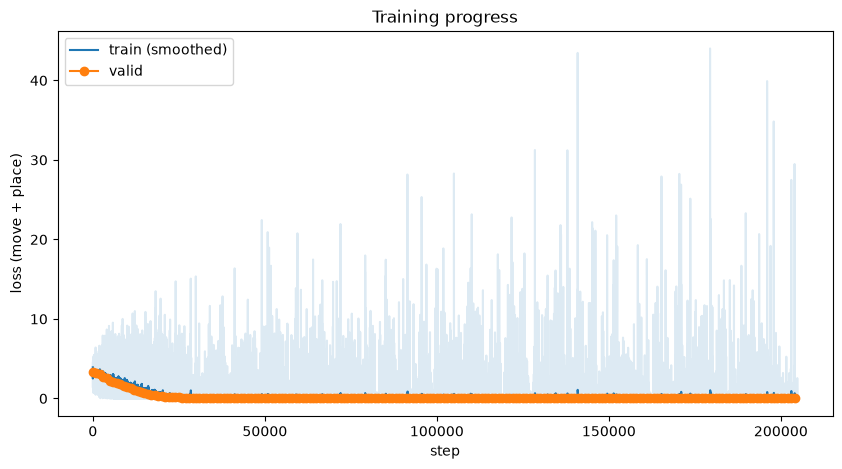

In [42]:
overfit_model = SimpleNN(d_model=1024)

small = train_records[:2048]
train_history, valid_history = train_fixed_subset(
    overfit_model, epochs=100, valid_every=1000, batch_size=4, subset=small
)


print(f"{num_params(overfit_model):>8}: loss: {valid_history[-1][1]:.4f}")

show_losses(train_history, valid_history)

In [45]:
#  12418: loss: 0.0577
#  6274 (but deeper): loss: 0.0069

In [43]:
class MovePlaceFFLayerCNN2D(nn.Module):
    def __init__(self, channels1: int, channels2: int, ff_factor: int) -> None:
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=channels1,
                kernel_size=(BOARD_SIZE - 2, BOARD_SIZE - 2),
                device=DEVICE,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=channels1,
                out_channels=channels2,
                kernel_size=(BOARD_SIZE - 1, BOARD_SIZE - 1),
                device=DEVICE,
            ),
            nn.Flatten(),
            nn.ReLU(),
        )
        self.ff = nn.Sequential(
            nn.Linear(channels2, channels2 * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels2 * ff_factor, channels2 * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels2 * ff_factor, channels2 * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels2 * ff_factor, channels2 * ff_factor, device=DEVICE),
            nn.ReLU(),
        )
        self.move_logits = nn.Linear(channels2 * ff_factor, MOVE_OPTIONS, device=DEVICE)
        self.place_logits = nn.Linear(
            channels2 * ff_factor, BOARD_SIZE * BOARD_SIZE, device=DEVICE
        )
        self.mask_move = mask_move_tensor_idxs_vectorized(DEVICE)
        self.mask_place = mask_place_tensor_idxs_vectorized(DEVICE)
        with torch.no_grad():
            self.move_logits.weight *= 0.1
            self.place_logits.weight *= 0.1

    def to_board_batch(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            return x[0].unsqueeze(0)
        elif x.dim() == 4:
            return x[:, 0]
        raise ValueError(f"Unexpected shape: {x.shape}")

    def forward(self, x, can_move: bool = True):
        conved = self.conv(x).view(-1)
        ff_x = self.ff(conved)
        board_batch = self.to_board_batch(x)

        out = (
            self.move_logits(ff_x) + self.mask_move(board_batch).squeeze(0)
            if can_move
            else self.place_logits(ff_x) + self.mask_place(board_batch).squeeze(0)
        )
        return out

    8578: loss: 0.0817


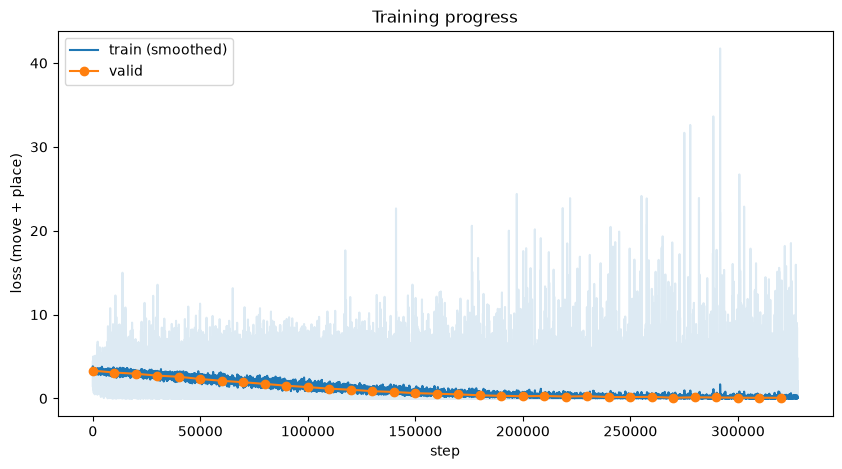

In [ ]:
overfit_model = MovePlaceFFLayerCNN2D(channels1=64, channels2=64, ff_factor=16)

small = train_records[:4096]
train_history, valid_history = train_fixed_subset(
    overfit_model, epochs=1, valid_every=10000, batch_size=16, subset=small
)


print(f"{num_params(overfit_model):>8}: loss: {valid_history[-1][1]:.4f}")

show_losses(train_history, valid_history)

In [24]:
class MovePlaceFFLayerCNN3D(nn.Module):
    def __init__(
        self, channels1: int, channels2: int, channels3: int, ff_factor: int
    ) -> None:
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=channels1,
                kernel_size=(BOARD_SIZE - 2, BOARD_SIZE - 2),
                device=DEVICE,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=channels1,
                out_channels=channels2,
                kernel_size=(BOARD_SIZE - 2, BOARD_SIZE - 2),
                device=DEVICE,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=channels2,
                out_channels=channels3,
                kernel_size=(BOARD_SIZE - 2, BOARD_SIZE - 2),
                device=DEVICE,
            ),
            nn.Flatten(),
            nn.ReLU(),
        )
        self.ff = nn.Sequential(
            nn.Linear(channels3, channels3 * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels3 * ff_factor, channels3 * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels3 * ff_factor, channels3 * ff_factor, device=DEVICE),
            nn.ReLU(),
            nn.Linear(channels3 * ff_factor, channels3 * ff_factor, device=DEVICE),
            nn.ReLU(),
        )
        self.move_logits = nn.Linear(channels3 * ff_factor, MOVE_OPTIONS, device=DEVICE)
        self.place_logits = nn.Linear(
            channels3 * ff_factor, BOARD_SIZE * BOARD_SIZE, device=DEVICE
        )
        self.mask_move = mask_move_tensor_idxs_vectorized(DEVICE)
        self.mask_place = mask_place_tensor_idxs_vectorized(DEVICE)
        with torch.no_grad():
            self.move_logits.weight *= 0.1
            self.place_logits.weight *= 0.1

    def to_board_batch(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            return x[0].unsqueeze(0)
        elif x.dim() == 4:
            return x[:, 0]
        raise ValueError(f"Unexpected shape: {x.shape}")

    def forward(self, x, can_move: bool = True):
        conved = self.conv(x).view(-1)
        ff_x = self.ff(conved)
        board_batch = self.to_board_batch(x)

        out = (
            self.move_logits(ff_x) + self.mask_move(board_batch).squeeze(0)
            if can_move
            else self.place_logits(ff_x) + self.mask_place(board_batch).squeeze(0)
        )
        return out

In [ ]:
overfit_model = MovePlaceFFLayerCNN3D(
    channels1=32, channels2=64, channels3=128, ff_factor=32
)

small = train_records[:4096]
train_history, valid_history = train_fixed_subset(
    overfit_model, epochs=100, valid_every=10000, batch_size=8, subset=small
)


print(f"{num_params(overfit_model):>8}: loss: {valid_history[-1][1]:.4f}")

show_losses(train_history, valid_history)

NameError: name 'num_params' is not defined

   33346: loss: 0.0951


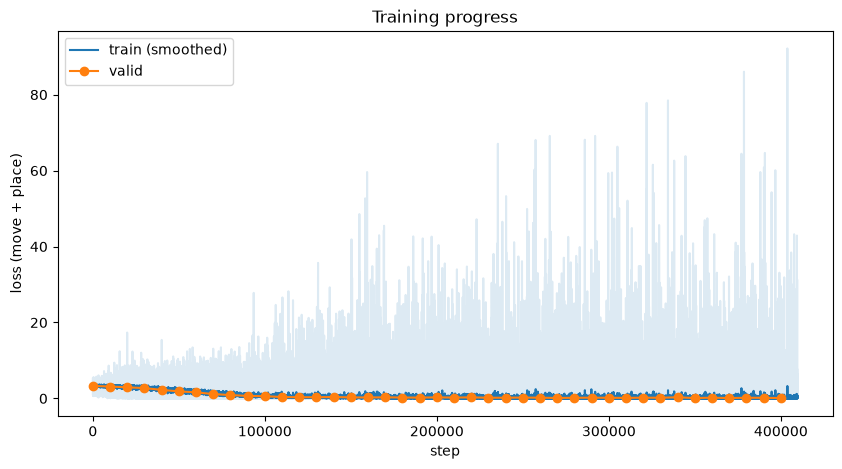

In [27]:
print(f"{num_params(overfit_model):>8}: loss: {valid_history[-1][1]:.4f}")

show_losses(train_history, valid_history)